# Car damage detection using Deep learning and Gen AI.

## Step 1:- Importing Libraries

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
from torch.utils.data import random_split
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Step 2: Data Understanding
### Data Augmentation and Preprocessing

In [ ]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])  #The specific number is from image net datasets, for tranfer learning we use resnet50 model, efficinet net etc
                                                                            # so the colour distribution has the mean and std of these values
])

In [ ]:
dataset_path = "./dataset"

dataset=datasets.ImageFolder(root = dataset_path, transform=image_transform)
len(dataset)

2300

# Step 3: Data Preparation

In [ ]:
class_names = dataset.classes

class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [ ]:
num_classes = len(dataset.classes)
num_classes

6

In [ ]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size
train_size, val_size

(1725, 575)

In [ ]:
#from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
labels[1]

tensor(1)

In [ ]:
images[1].shape

torch.Size([3, 224, 224])

In [ ]:
images[1].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216995].


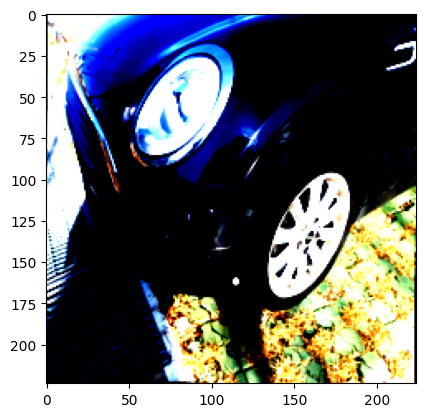

In [ ]:
plt.imshow(images[1].permute(1,2,0))
plt.show()

# Step 4: Modeling
### Model 1. Build a CNN Model

In [ ]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224) 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)           
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.network(x)
        return x

In [ ]:
# Instantiate the model, loss Function, and optimizer

model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_model(model, criterion, optimizer, epochs=50):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")
        
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [ ]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=50)

Batch: 10, Epoch: 1, Loss: 1.76
Batch: 20, Epoch: 1, Loss: 1.49
Batch: 30, Epoch: 1, Loss: 1.58
Batch: 40, Epoch: 1, Loss: 1.19
Batch: 50, Epoch: 1, Loss: 1.40
Epoch [1/50], Avg Loss: 1.7089
*** Validation Accuracy: 39.48% ***
Batch: 10, Epoch: 2, Loss: 1.39
Batch: 20, Epoch: 2, Loss: 1.09
Batch: 30, Epoch: 2, Loss: 1.11
Batch: 40, Epoch: 2, Loss: 1.24
Batch: 50, Epoch: 2, Loss: 1.37
Epoch [2/50], Avg Loss: 1.2000
*** Validation Accuracy: 46.61% ***
Batch: 10, Epoch: 3, Loss: 1.14
Batch: 20, Epoch: 3, Loss: 0.99
Batch: 30, Epoch: 3, Loss: 1.13
Batch: 40, Epoch: 3, Loss: 1.25
Batch: 50, Epoch: 3, Loss: 1.01
Epoch [3/50], Avg Loss: 1.0510
*** Validation Accuracy: 51.48% ***
Batch: 10, Epoch: 4, Loss: 1.02
Batch: 20, Epoch: 4, Loss: 0.80
Batch: 30, Epoch: 4, Loss: 1.21
Batch: 40, Epoch: 4, Loss: 1.23
Batch: 50, Epoch: 4, Loss: 0.86
Epoch [4/50], Avg Loss: 0.9457
*** Validation Accuracy: 52.70% ***
Batch: 10, Epoch: 5, Loss: 1.03
Batch: 20, Epoch: 5, Loss: 0.86
Batch: 30, Epoch: 5, Loss: 0

### Model 2. CNN with Regularisation

In [ ]:


class CarClassifierCNNWithRegularisation(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224) 
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)           
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.network(x)
        return x

In [ ]:
model = CarClassifierCNNWithRegularisation(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


all_labels, all_predictions = train_model(model, criterion, optimizer,  epochs=100)

Batch: 10, Epoch: 1, Loss: 18.77
Batch: 20, Epoch: 1, Loss: 4.81
Batch: 30, Epoch: 1, Loss: 1.73
Batch: 40, Epoch: 1, Loss: 1.59
Batch: 50, Epoch: 1, Loss: 1.76
Epoch [1/100], Avg Loss: 8.3323
*** Validation Accuracy: 37.22% ***
Batch: 10, Epoch: 2, Loss: 1.60
Batch: 20, Epoch: 2, Loss: 1.43
Batch: 30, Epoch: 2, Loss: 1.38
Batch: 40, Epoch: 2, Loss: 1.48
Batch: 50, Epoch: 2, Loss: 1.17
Epoch [2/100], Avg Loss: 1.5156
*** Validation Accuracy: 42.96% ***
Batch: 10, Epoch: 3, Loss: 1.69
Batch: 20, Epoch: 3, Loss: 1.47
Batch: 30, Epoch: 3, Loss: 1.39
Batch: 40, Epoch: 3, Loss: 1.38
Batch: 50, Epoch: 3, Loss: 1.54
Epoch [3/100], Avg Loss: 1.3708
*** Validation Accuracy: 45.04% ***
Batch: 10, Epoch: 4, Loss: 1.33
Batch: 20, Epoch: 4, Loss: 1.24
Batch: 30, Epoch: 4, Loss: 1.45
Batch: 40, Epoch: 4, Loss: 1.16
Batch: 50, Epoch: 4, Loss: 1.37
Epoch [4/100], Avg Loss: 1.3764
*** Validation Accuracy: 46.09% ***
Batch: 10, Epoch: 5, Loss: 1.50
Batch: 20, Epoch: 5, Loss: 1.66
Batch: 30, Epoch: 5, Lo

 #### Model 3 : Transfer Learning with EfficientNet

In [ ]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x 

In [ ]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs= 100)

Batch: 10, Epoch: 1, Loss: 1.62
Batch: 20, Epoch: 1, Loss: 1.62
Batch: 30, Epoch: 1, Loss: 1.41
Batch: 40, Epoch: 1, Loss: 1.38
Batch: 50, Epoch: 1, Loss: 1.17
Epoch [1/100], Avg Loss: 1.4802
*** Validation Accuracy: 56.00% ***
Batch: 10, Epoch: 2, Loss: 1.13
Batch: 20, Epoch: 2, Loss: 1.05
Batch: 30, Epoch: 2, Loss: 1.28
Batch: 40, Epoch: 2, Loss: 1.08
Batch: 50, Epoch: 2, Loss: 0.96
Epoch [2/100], Avg Loss: 1.1347
*** Validation Accuracy: 60.35% ***
Batch: 10, Epoch: 3, Loss: 1.08
Batch: 20, Epoch: 3, Loss: 1.13
Batch: 30, Epoch: 3, Loss: 0.93
Batch: 40, Epoch: 3, Loss: 1.22
Batch: 50, Epoch: 3, Loss: 1.01
Epoch [3/100], Avg Loss: 1.0092
*** Validation Accuracy: 61.57% ***
Batch: 10, Epoch: 4, Loss: 1.05
Batch: 20, Epoch: 4, Loss: 1.01
Batch: 30, Epoch: 4, Loss: 0.80
Batch: 40, Epoch: 4, Loss: 0.84
Batch: 50, Epoch: 4, Loss: 0.99
Epoch [4/100], Avg Loss: 0.9452
*** Validation Accuracy: 60.17% ***
Batch: 10, Epoch: 5, Loss: 0.73
Batch: 20, Epoch: 5, Loss: 0.84
Batch: 30, Epoch: 5, Los

### Model 4: Transfer Learning with ResNet

In [ ]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [ ]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=100)

Batch: 10, Epoch: 1, Loss: 0.96
Batch: 20, Epoch: 1, Loss: 0.71
Batch: 30, Epoch: 1, Loss: 0.69
Batch: 40, Epoch: 1, Loss: 0.68
Batch: 50, Epoch: 1, Loss: 0.85
Epoch [1/100], Avg Loss: 0.8786
*** Validation Accuracy: 72.52% ***
Batch: 10, Epoch: 2, Loss: 0.53
Batch: 20, Epoch: 2, Loss: 0.56
Batch: 30, Epoch: 2, Loss: 1.07
Batch: 40, Epoch: 2, Loss: 0.40
Batch: 50, Epoch: 2, Loss: 0.48
Epoch [2/100], Avg Loss: 0.4970
*** Validation Accuracy: 76.70% ***
Batch: 10, Epoch: 3, Loss: 0.15
Batch: 20, Epoch: 3, Loss: 0.14
Batch: 30, Epoch: 3, Loss: 0.32
Batch: 40, Epoch: 3, Loss: 0.41
Batch: 50, Epoch: 3, Loss: 0.39
Epoch [3/100], Avg Loss: 0.3366
*** Validation Accuracy: 78.78% ***
Batch: 10, Epoch: 4, Loss: 0.33
Batch: 20, Epoch: 4, Loss: 0.35
Batch: 30, Epoch: 4, Loss: 0.31
Batch: 40, Epoch: 4, Loss: 0.27
Batch: 50, Epoch: 4, Loss: 0.27
Epoch [4/100], Avg Loss: 0.2839
*** Validation Accuracy: 80.35% ***
Batch: 10, Epoch: 5, Loss: 0.04
Batch: 20, Epoch: 5, Loss: 0.07
Batch: 30, Epoch: 5, Los

## Step 6: Hyperparameter tunning for resnet models are (1) Dropout rate = 0.2 (2) Learning Rate = 0.005, Training the model once again with these best parameters

In [ ]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.005)

labels, predictions = train_model(model, criterion, optimizer, epochs=100)

Batch: 10, Epoch: 1, Loss: 0.86
Batch: 20, Epoch: 1, Loss: 0.87
Batch: 30, Epoch: 1, Loss: 0.61
Batch: 40, Epoch: 1, Loss: 0.70
Batch: 50, Epoch: 1, Loss: 0.59
Epoch [1/100], Avg Loss: 0.8701
*** Validation Accuracy: 68.35% ***
Batch: 10, Epoch: 2, Loss: 0.55
Batch: 20, Epoch: 2, Loss: 0.86
Batch: 30, Epoch: 2, Loss: 0.39
Batch: 40, Epoch: 2, Loss: 0.45
Batch: 50, Epoch: 2, Loss: 0.70
Epoch [2/100], Avg Loss: 0.5367
*** Validation Accuracy: 74.96% ***
Batch: 10, Epoch: 3, Loss: 0.43
Batch: 20, Epoch: 3, Loss: 0.36
Batch: 30, Epoch: 3, Loss: 0.57
Batch: 40, Epoch: 3, Loss: 0.75
Batch: 50, Epoch: 3, Loss: 0.23
Epoch [3/100], Avg Loss: 0.3912
*** Validation Accuracy: 80.00% ***
Batch: 10, Epoch: 4, Loss: 0.15
Batch: 20, Epoch: 4, Loss: 0.40
Batch: 30, Epoch: 4, Loss: 0.34
Batch: 40, Epoch: 4, Loss: 0.10
Batch: 50, Epoch: 4, Loss: 0.39
Epoch [4/100], Avg Loss: 0.3293
*** Validation Accuracy: 77.22% ***
Batch: 10, Epoch: 5, Loss: 0.30
Batch: 20, Epoch: 5, Loss: 0.38
Batch: 30, Epoch: 5, Los

# Step 7: Evaluation
### Analyze Model Performance

In [ ]:


report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       108
           1       0.86      0.84      0.85       110
           2       0.91      0.92      0.91       121
           3       0.85      0.69      0.76        75
           4       0.73      0.82      0.78        84
           5       0.81      0.83      0.82        77

    accuracy                           0.85       575
   macro avg       0.84      0.84      0.84       575
weighted avg       0.85      0.85      0.85       575



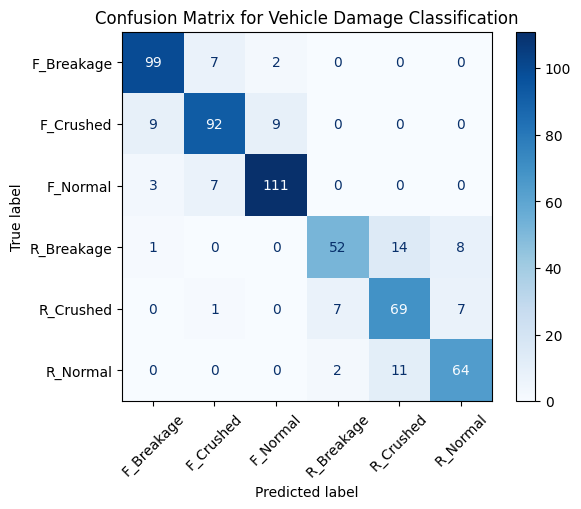

In [ ]:
conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

# Step 8: Deployment

C:\Users\malav\AppData\Local\Temp\ipykernel_44560\3396932658.py:103: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\malav\AppData\Local\Temp\ipykernel_44560\3396932658.py:103: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\malav\AppData\Local\Temp\ipykernel_44560\3396932658.py:104: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig('combined_visualizations.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
C:\Users\malav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


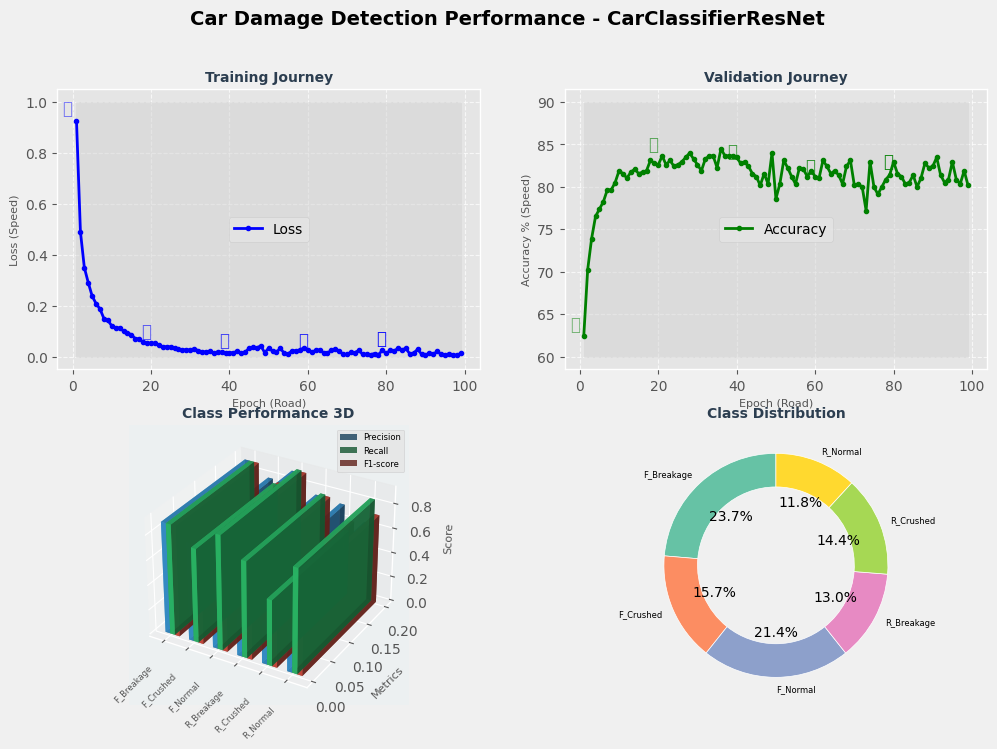

In [ ]:

# Use a valid Matplotlib style
plt.style.use('ggplot')

# Create a single figure with subplots (smaller size)
fig = plt.figure(figsize=(12, 8), facecolor='#f0f0f0')  # Reduced from 15x10 to 12x8
fig.suptitle('Car Damage Detection Performance - CarClassifierResNet', fontsize=14, fontweight='bold')

# 1. Training Loss Curve (Enhanced Car Moving Style)
ax1 = plt.subplot(2, 2, 1)
epochs = range(1, len(train_losses) + 1)
ax1.fill_between(epochs, 0, 1, color='#d3d3d3', alpha=0.5)  # Road background
ax1.plot(epochs, train_losses, 'b-', linewidth=2, marker='o', markersize=3, label='Loss')
ax1.set_title('Training Journey', fontsize=10, fontweight='bold', color='#2c3e50')
ax1.set_xlabel('Epoch (Road)', fontsize=8)
ax1.set_ylabel('Loss (Speed)', fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()
# Fixed alpha range for car movement
for i in range(0, len(epochs), 20):  # Show car every 20 epochs
    alpha_value = 0.5 + (0.5 * i / len(epochs))  # Scales from 0.5 to 1.0
    ax1.annotate('🚗', xy=(epochs[i], train_losses[i]), xytext=(-10, 5), 
                 textcoords='offset points', fontsize=12, color='blue', alpha=alpha_value)

# 2. Validation Accuracy Curve (Enhanced Car Moving Style)
ax2 = plt.subplot(2, 2, 2)
ax2.fill_between(epochs, 60, 90, color='#d3d3d3', alpha=0.5)  # Road background
ax2.plot(epochs, val_accuracies, 'g-', linewidth=2, marker='o', markersize=3, label='Accuracy')
ax2.set_title('Validation Journey', fontsize=10, fontweight='bold', color='#2c3e50')
ax2.set_xlabel('Epoch (Road)', fontsize=8)
ax2.set_ylabel('Accuracy % (Speed)', fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()
# Fixed alpha range for car movement
for i in range(0, len(epochs), 20):  # Show car every 20 epochs
    alpha_value = 0.5 + (0.5 * i / len(epochs))  # Scales from 0.5 to 1.0
    ax2.annotate('🚗', xy=(epochs[i], val_accuracies[i]), xytext=(-10, 5), 
                 textcoords='offset points', fontsize=12, color='green', alpha=alpha_value)

# 3. 3D Bar Chart for Class-wise Performance
ax3 = plt.subplot(2, 2, 3, projection='3d')
x = np.arange(len(class_names))
width = 0.2
ax3.bar3d(x - width, np.zeros(len(precision)), np.zeros(len(precision)), width, width, precision, color='#3498db', alpha=0.8, label='Precision')
ax3.bar3d(x, np.zeros(len(recall)), np.zeros(len(recall)), width, width, recall, color='#2ecc71', alpha=0.8, label='Recall')
ax3.bar3d(x + width, np.zeros(len(f1_score)), np.zeros(len(f1_score)), width, width, f1_score, color='#e74c3c', alpha=0.8, label='F1-score')
ax3.set_title('Class Performance 3D', fontsize=10, fontweight='bold', color='#2c3e50')
ax3.set_xticks(x)
ax3.set_xticklabels(class_names, rotation=45, ha='right', fontsize=6)
ax3.set_ylabel('Metrics', fontsize=8)
ax3.set_zlabel('Score', fontsize=8)
ax3.legend(fontsize=6)
ax3.set_facecolor('#ecf0f1')

# 4. Donut Chart for Class Distribution
ax4 = plt.subplot(2, 2, 4)
wedges, texts, autotexts = ax4.pie(support, labels=class_names, autopct='%1.1f%%', 
                                  startangle=90, colors=sns.color_palette('Set2'),
                                  wedgeprops=dict(width=0.3, edgecolor='w'))
ax4.set_title('Class Distribution', fontsize=10, fontweight='bold', color='#2c3e50')
for text in texts:
    text.set_fontsize(6)
for autotext in autotexts:
    text.set_fontsize(6)

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('combined_visualizations.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Saving Model for Future Use

In [ ]:
# Save only the state_dict (weights)
torch.save(model.state_dict(), "car_damage_detection_model.pth")